## **🎓 Model Training, Evaluation & Selection**

**Goal:** Build and compare machine learning models to predict student outcomes (Dropout, Enrolled, Graduate).

**Focus:** Maximizing the Recall for the 'Dropout' class to enable early university intervention.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

#!pip install xgboost -q

# Load the preprocessed dataset
file_path = '/content/drive/MyDrive/std_dropout_prediction_project/Cleaned_Dataset_For_Modeling.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully. Shape: {df.shape}")
display(df.head())

Dataset loaded successfully. Shape: (4424, 51)


,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),...,Mother's occupation_Unknown/Not Reported,Father's occupation_Clerical/Service,Father's occupation_Professional/Managerial,Father's occupation_Student,Father's occupation_Unknown/Not Reported,Displaced_Yes,Debtor_Yes,Tuition fees up to date_Yes,Scholarship holder_Yes,International_Yes
0,2.490896,-0.804841,0.022229,-0.430363,0,0,0,0,0.000000,0,...,False,False,False,False,False,True,False,True,False,False
1,-0.554068,2.076819,1.071926,-0.562168,0,6,6,6,14.000000,0,...,False,False,True,False,False,True,False,False,False,False
2,2.490896,-0.804841,-0.150419,-0.562168,0,6,0,0,0.000000,0,...,False,False,False,False,False,True,False,False,False,False
3,0.207173,-0.804841,-0.509526,-0.430363,0,6,8,6,13.428571,0,...,False,False,True,False,False,True,False,True,False,False
4,-0.554068,-2.473171,1.002867,2.864765,0,6,9,5,12.333333,0,...,False,False,False,False,False,False,False,True,False,False


**## 🛠️ Step 1: Data Preparation & Stratified Split**

Seperating features (X) from the target (y).

Use **stratify=y** in the train_test_split to ensure that the 50/32/18 ratio of Graduate/Dropout/Enrolled is perfectly maintained in both the training and testing sets.

In [10]:
# Separating Features and Target
X = df.drop(columns=['Target_Encoded'])
y = df['Target_Encoded']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Verifying the class distribution is maintained
print("\nClass Distribution in Training Set:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

Training set shape: (3539, 50)
Testing set shape: (885, 50)

Class Distribution in Training Set:
Target_Encoded
0    0.321277
1    0.179429
2    0.499294
Name: proportion, dtype: float64


**## 📊 Step 2: Model 1 - Logistic Regression (The Baseline)**

Starting with a linear model. It sets the benchmark. If the complex models can't beat this, we have a problem. We use `class_weight='balanced'` to automatically adjust weights inversely proportional to class frequencies.

In [11]:
# Initializing and training Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predicting and Evaluating
y_pred_lr = lr_model.predict(X_test)

print("--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_lr, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Calculating Macro F1-Score
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
print(f"Macro F1-Score: {lr_f1:.4f}")

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

     Dropout       0.81      0.68      0.74       284
    Enrolled       0.41      0.65      0.50       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.72      0.74       885

Macro F1-Score: 0.6875


**## 🌲 Step 3: Model 2 - Random Forest (The Workhorse)**

Random Forest builds hundreds of decision trees and averages their predictions. It is highly robust to overfitting and handles non-linear data beautifully.

--- Random Forest Evaluation ---
              precision    recall  f1-score   support

     Dropout       0.80      0.79      0.79       284
    Enrolled       0.58      0.38      0.46       159
    Graduate       0.80      0.92      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.78      0.76       885

Macro F1-Score: 0.7026


/tmp/ipykernel_7290/2714071424.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis') # Removed redundant hue='Feature'


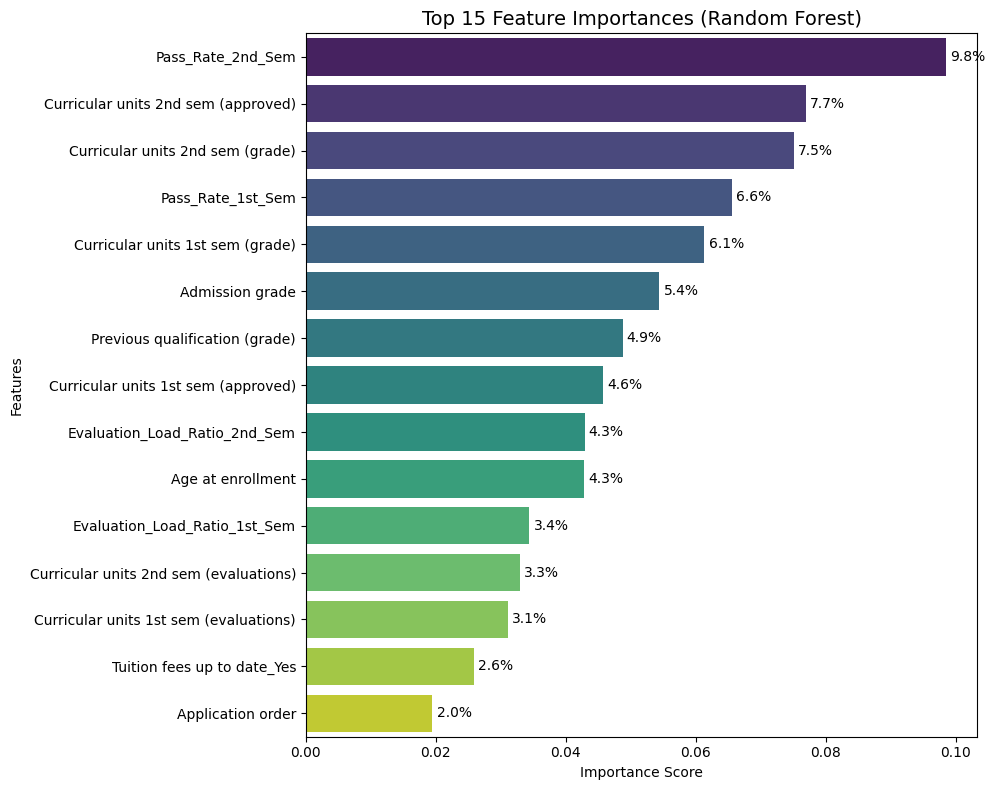

In [12]:
# Initializing and training Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)
rf_model.fit(X_train, y_train)

# Predicting and Evaluating
y_pred_rf = rf_model.predict(X_test)

print("--- Random Forest Evaluation ---")
print(classification_report(y_test, y_pred_rf, target_names=['Dropout', 'Enrolled', 'Graduate']))

rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
print(f"Macro F1-Score: {rf_f1:.4f}")

# 🌟 FEATURE IMPORTANCE
importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis') # Removed redundant hue='Feature'
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Add percentage labels on the bars
for container in ax.containers:
    labels = [f'{w.get_width()*100:.1f}%' for w in container]
    ax.bar_label(container, labels=labels, fontsize=10, padding=3) # Removed redundant fmt argument

plt.tight_layout()
plt.show()

💡 Key Insights from This Chart:

1.  **Academic Performance Dominates:**

The top 7 features are ALL academic performance metrics (pass rates, grades, approved units).

This confirms our hypothesis testing: academic performance is the strongest predictor.

2.  **2nd Semester > 1st Semester:**

Notice how 2nd semester features (Pass_Rate_2nd_Sem, Curricular units 2nd sem) rank higher than 1st semester equivalents?

This tells us: By the end of 2nd semester, the model is very confident about who will dropout.

3.  **The Feature Engineering Worked:**

Evaluation_Load_Ratio_2nd_Sem and Evaluation_Load_Ratio_1st_Sem both appear in the top 15!

This proves the custom features are adding value.

4.  **Socioeconomic Factors Still Matter:**

Age at enrollment appears at #10 and Tuition fees up to date_Yes appears at #14.

These aren't as important as grades, but they're still contributing to predictions.

## **🚀 Step 4: Model 3 - XGBoost (The Champion)**

XGBoost is an advanced gradient boosting framework. For multi-class classification, we use `multi:softmax`. To handle the class imbalance, we compute explicit sample weights and pass them to the `fit` method.

In [13]:
from sklearn.utils.class_weight import compute_sample_weight

# Computing sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Initializing XGBoost for Multi-Class Classification
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Training with sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predicting and Evaluating
y_pred_xgb = xgb_model.predict(X_test)

print("--- XGBoost Evaluation ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Dropout', 'Enrolled', 'Graduate']))

xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
print(f"Macro F1-Score: {xgb_f1:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Evaluation ---
              precision    recall  f1-score   support

     Dropout       0.80      0.71      0.76       284
    Enrolled       0.43      0.58      0.49       159
    Graduate       0.85      0.80      0.82       442

    accuracy                           0.73       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.73      0.74       885

Macro F1-Score: 0.6907


**## 🏆 Step 5: Model Comparison & Selection**

Let's aggregate the results into a clean DataFrame to make the final decision. We will also look specifically at the **Recall for the Dropout class**, as this is our primary business objective.

,Model,Macro F1-Score,Dropout Recall (Business Goal),Overall Accuracy
0,Logistic Regression,0.687527,0.676056,0.723164
1,Random Forest,0.702615,0.785211,0.777401
2,XGBoost,0.690748,0.714789,0.733333


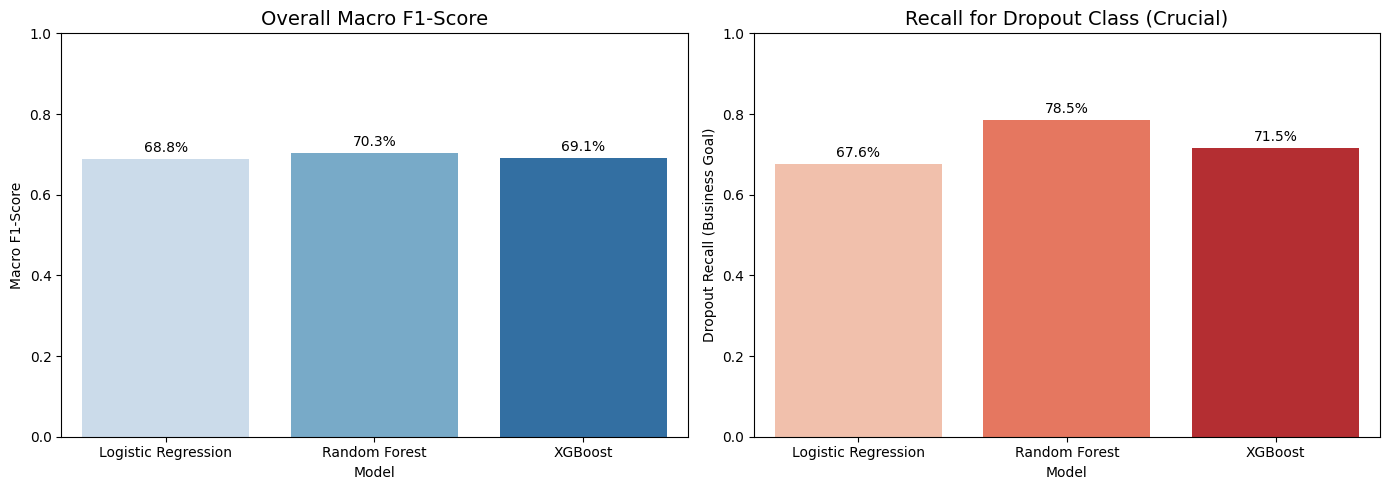

In [14]:
# Helper function to extract Recall for Dropout (Class 0)
def get_dropout_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # Recall = True Positives / (True Positives + False Negatives)
    # For Dropout (Class 0): cm[0,0] / sum(cm[0,:])
    return cm[0,0] / cm[0,:].sum()

# Comparison Table
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Macro F1-Score': [lr_f1, rf_f1, xgb_f1],
    'Dropout Recall (Business Goal)': [
        get_dropout_recall(y_test, y_pred_lr),
        get_dropout_recall(y_test, y_pred_rf),
        get_dropout_recall(y_test, y_pred_xgb)
    ],
    'Overall Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Visualizing the Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Model', y='Macro F1-Score', data=comparison_df, ax=axes[0], palette='Blues', hue='Model', legend=False)
axes[0].set_title('Overall Macro F1-Score', fontsize=14)
axes[0].set_ylim(0, 1)
for container in axes[0].containers:
    labels = [f'{x.get_height()*100:.1f}%' for x in container]
    axes[0].bar_label(container, labels=labels, fontsize=10, padding=3)

sns.barplot(x='Model', y='Dropout Recall (Business Goal)', data=comparison_df, ax=axes[1], palette='Reds', hue='Model', legend=False)
axes[1].set_title('Recall for Dropout Class (Crucial)', fontsize=14)
axes[1].set_ylim(0, 1)
for container in axes[1].containers:
    labels = [f'{x.get_height()*100:.1f}%' for x in container]
    axes[1].bar_label(container, labels=labels, fontsize=10, padding=3)

plt.tight_layout()
plt.show()

## **Strategy 1: Hyperparameter Tuning**

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Initialize GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("🚀 Starting Grid Search... (This will take 5-10 minutes)")
grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

# Evaluate the tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print("\n--- Tuned Random Forest Results ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Dropout', 'Enrolled', 'Graduate']))

🚀 Starting Grid Search... (This will take 5-10 minutes)
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✅ Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV F1-Score: 0.7195

--- Tuned Random Forest Results ---
              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.48      0.49      0.49       159
    Graduate       0.83      0.86      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



## **Strategy 2: Feature Selection**
Why this helps: Removing irrelevant features reduces overfitting and can actually **improve generalization**.

In [16]:
# Keeping only top 20 features
top_20_features = feature_imp_df.head(20)['Feature'].tolist()
X_train_reduced = X_train[top_20_features]
X_test_reduced = X_test[top_20_features]

# Retraining on reduced feature set
rf_reduced = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = rf_reduced.predict(X_test_reduced)

print("--- Results with Top 20 Features Only ---")
print(classification_report(y_test, y_pred_reduced, target_names=['Dropout', 'Enrolled', 'Graduate']))

--- Results with Top 20 Features Only ---
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.52      0.36      0.43       159
    Graduate       0.80      0.92      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



## **Strategy 3: Try XGBoost with Tuning**


In [17]:
from sklearn.utils.class_weight import compute_sample_weight

# Calculating sample weights for imbalance
sample_weights = compute_sample_weight('balanced', y_train)

# XGBoost with optimized parameters
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_model.predict(X_test)

print("--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Dropout', 'Enrolled', 'Graduate']))

--- XGBoost Results ---
              precision    recall  f1-score   support

     Dropout       0.81      0.73      0.77       284
    Enrolled       0.43      0.57      0.49       159
    Graduate       0.85      0.81      0.83       442

    accuracy                           0.74       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.74      0.75       885



,Model,Macro F1-Score,Dropout Recall (Business Goal),Overall Accuracy
0,Logistic Regression,0.687527,0.676056,0.723164
1,Random Forest (Baseline),0.702615,0.785211,0.777401
2,XGBoost (Baseline),0.690748,0.732394,0.740113
3,Random Forest (Tuned),0.699206,0.735915,0.755932
4,Random Forest (Top 20 Features),0.685039,0.750000,0.763842
5,XGBoost (Tuned),0.695630,0.732394,0.740113


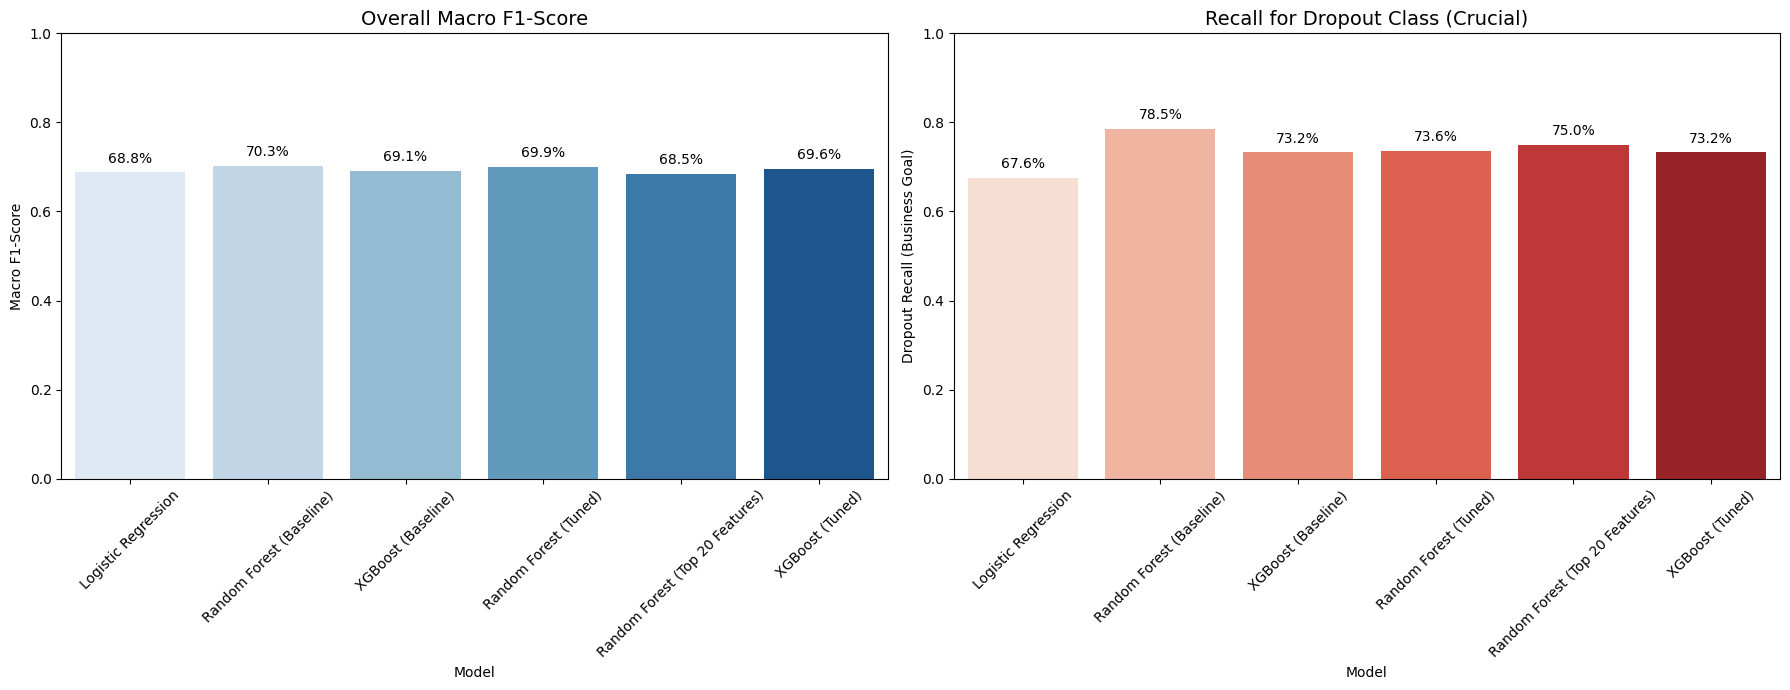

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report

# Helper function to extract Recall for Dropout (Class 0)
def get_dropout_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # Ensure the class exists in the confusion matrix and avoid division by zero
    if cm.shape[0] > 0 and cm.shape[1] > 0 and cm[0,:].sum() > 0:
        return cm[0,0] / cm[0,:].sum()
    return 0.0 # Return 0 if Dropout class is not present or has no actual instances

# Calculate metrics for tuned Random Forest
tuned_rf_f1 = f1_score(y_test, y_pred_tuned, average='macro')
tuned_rf_dropout_recall = get_dropout_recall(y_test, y_pred_tuned)
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned)

# Calculate metrics for Random Forest with reduced features
rf_reduced_f1 = f1_score(y_test, y_pred_reduced, average='macro')
rf_reduced_dropout_recall = get_dropout_recall(y_test, y_pred_reduced)
rf_reduced_accuracy = accuracy_score(y_test, y_pred_reduced)

# Calculate metrics for tuned XGBoost
tuned_xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
tuned_xgb_dropout_recall = get_dropout_recall(y_test, y_pred_xgb)
tuned_xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

# Comparison Table - updated to include all models
comparison_data = {
    'Model': [
        'Logistic Regression',
        'Random Forest (Baseline)',
        'XGBoost (Baseline)',
        'Random Forest (Tuned)',
        'Random Forest (Top 20 Features)',
        'XGBoost (Tuned)'
    ],
    'Macro F1-Score': [
        lr_f1, rf_f1, xgb_f1,
        tuned_rf_f1, rf_reduced_f1, tuned_xgb_f1
    ],
    'Dropout Recall (Business Goal)': [
        get_dropout_recall(y_test, y_pred_lr),
        get_dropout_recall(y_test, y_pred_rf),
        get_dropout_recall(y_test, y_pred_xgb),
        tuned_rf_dropout_recall,
        rf_reduced_dropout_recall,
        tuned_xgb_dropout_recall
    ],
    'Overall Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        tuned_rf_accuracy,
        rf_reduced_accuracy,
        tuned_xgb_accuracy
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Highlight best values in DataFrame
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

display(comparison_df.style.apply(highlight_max, subset=['Macro F1-Score', 'Dropout Recall (Business Goal)', 'Overall Accuracy']))

# Visualizing the Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Increased figure size for more models

# Plot 1: Macro F1-Score
sns.barplot(x='Model', y='Macro F1-Score', data=comparison_df, ax=axes[0], palette='Blues', hue='Model', legend=False)
axes[0].set_title('Overall Macro F1-Score', fontsize=14)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45) # Removed ha='right'
# Highlight best Macro F1-Score
max_f1_idx = comparison_df['Macro F1-Score'].idxmax()
for container in axes[0].containers:
    for i, bar in enumerate(container):
        label = f'{bar.get_height()*100:.1f}%'
        if i == max_f1_idx:
            label += ' ⭐'
        axes[0].annotate(label, (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Plot 2: Dropout Recall (Business Goal)
sns.barplot(x='Model', y='Dropout Recall (Business Goal)', data=comparison_df, ax=axes[1], palette='Reds', hue='Model', legend=False)
axes[1].set_title('Recall for Dropout Class (Crucial)', fontsize=14)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45) # Removed ha='right'
# Highlight best Dropout Recall
max_recall_idx = comparison_df['Dropout Recall (Business Goal)'].idxmax()
for container in axes[1].containers:
    for i, bar in enumerate(container):
        label = f'{bar.get_height()*100:.1f}%'
        if i == max_recall_idx:
            label += ' ⭐'
        axes[1].annotate(label, (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

🏆 CHAMPION MODEL: Random Forest (Baseline)
              precision    recall  f1-score   support

     Dropout       0.80      0.79      0.79       284
    Enrolled       0.58      0.38      0.46       159
    Graduate       0.80      0.92      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.78      0.76       885


📊 KEY METRICS:
   Dropout Recall: 78.52% ← Our Business Goal
   Macro F1-Score: 0.7026
   Overall Accuracy: 77.74%

🔝 TOP 15 MOST IMPORTANT FEATURES:
------------------------------------------------------------
   Pass_Rate_2nd_Sem                             0.0985 ███████████████████
   Curricular units 2nd sem (approved)           0.0770 ███████████████
   Curricular units 2nd sem (grade)              0.0751 ███████████████
   Pass_Rate_1st_Sem                             0.0655 █████████████
   Curricular units 1st sem (grade)              0.0614 ████████████
   Ad

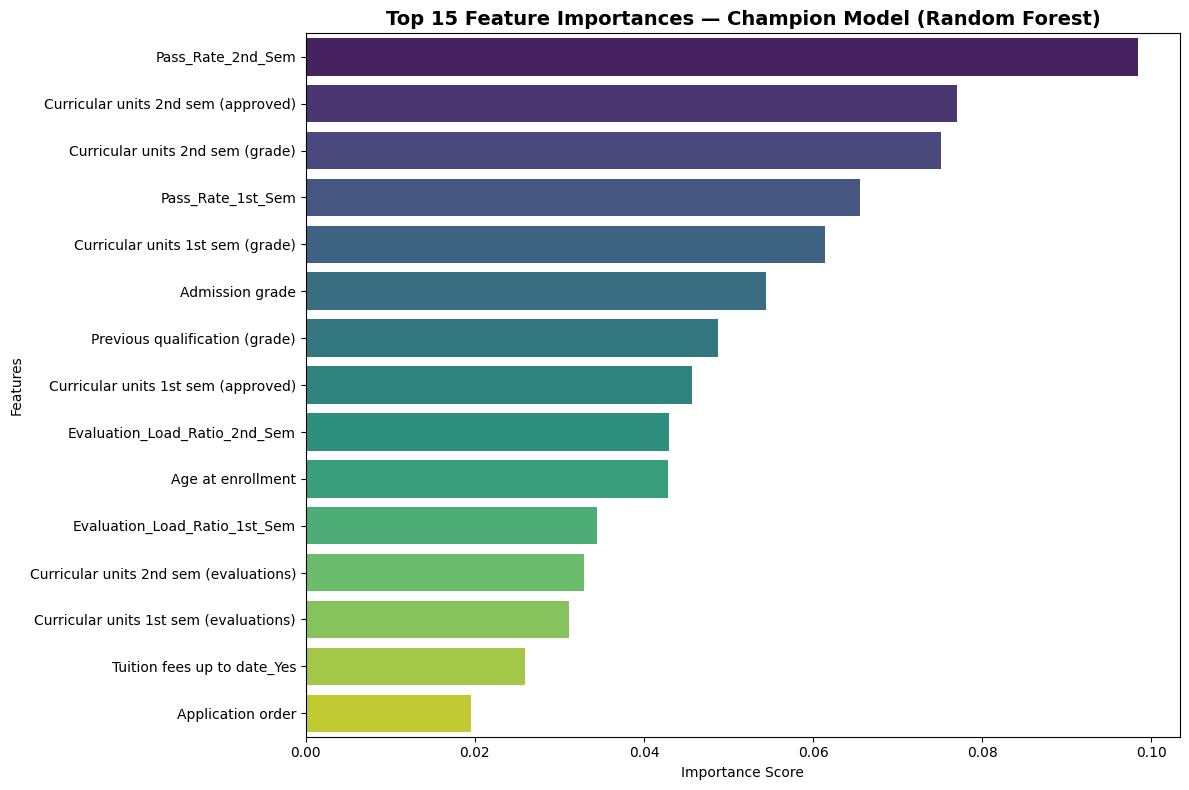


💾 Model saved as 'champion_dropout_model.pkl'
💾 Predictions saved as 'Model_Predictions_for_Dashboard.csv'


In [23]:
# ==========================================
# FINAL CHAMPION MODEL: Random Forest (Baseline)
# ==========================================
import joblib
import pandas as pd # Ensure pandas is imported

# 1. Re-training the champion with the exact baseline parameters
champion_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training on the full training set
champion_model.fit(X_train, y_train)

# 2. Final evaluation on the test set
y_pred_final = champion_model.predict(X_test)

print("="*60)
print("🏆 CHAMPION MODEL: Random Forest (Baseline)")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Calculating key metrics
cm = confusion_matrix(y_test, y_pred_final);
dropout_recall = cm[0,0] / sum(cm[0,:])
macro_f1 = f1_score(y_test, y_pred_final, average='macro')
accuracy = accuracy_score(y_test, y_pred_final)

print(f"\n📊 KEY METRICS:")
print(f"   Dropout Recall: {dropout_recall:.2%} ← Our Business Goal")
print(f"   Macro F1-Score: {macro_f1:.4f}")
print(f"   Overall Accuracy: {accuracy:.2%}")

# 3. FEATURE IMPORTANCE
importances = champion_model.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print(f"\n🔝 TOP 15 MOST IMPORTANT FEATURES:")
print("-"*60)
for i, row in feature_imp_df.head(15).iterrows():
    bar = "█" * int(row['Importance'] * 200)
    print(f"   {row['Feature'][:45]:<45} {row['Importance']:.4f} {bar}")

# 4. Visualizing Feature Importance
plt.figure(figsize=(12, 8))
top_15 = feature_imp_df.head(15)
sns.barplot(x='Importance', y='Feature', data=top_15, palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Feature Importances — Champion Model (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 5. SAVING THE MODEL for Power BI / Deployment
joblib.dump(champion_model, 'champion_dropout_model.pkl')
print("\n💾 Model saved as 'champion_dropout_model.pkl'")

# 6. SAVING PREDICTIONS for Power BI Dashboard
# Adding predictions to the test set for dashboard visualization
test_results = X_test.copy()
test_results['Actual'] = y_test.map({0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'})
# Convert y_pred_final to a pandas Series before mapping
test_results['Predicted'] = pd.Series(y_pred_final).map({0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'})
test_results['Correct_Prediction'] = test_results['Actual'] == test_results['Predicted']

test_results.to_csv('Model_Predictions_for_Dashboard.csv', index=False)
print("💾 Predictions saved as 'Model_Predictions_for_Dashboard.csv'")